# Redes neuronales secuenciales | Iris

Clasifico las tres especies de Iris con redes secuenciales de Keras y pruebo si usar solo el pétalo iguala a las cuatro variables.

## 1. Comprensión del negocio

¿Qué medidas alcanzan para identificar la especie? Para aislar el efecto de las features mantengo la arquitectura y solo cambio las entradas.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

tf.get_logger().setLevel("ERROR")

np.random.seed(42)
tf.random.set_seed(42)
keras.utils.set_random_seed(42)

sns.set_theme(style="whitegrid", palette="deep")
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.16.2 | Keras 3.10.0


## 2. Comprensión de los datos

Cargo el csv crudo: cuatro medidas más la especie.

In [2]:
cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv("data/iris.data", header=None, names=cols).dropna().reset_index(drop=True)
df["species"] = df["species"].str.replace("Iris-", "", regex=False)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape, df["species"].value_counts().to_dict(), int(df.isnull().sum().sum())

((150, 5), {'setosa': 50, 'versicolor': 50, 'virginica': 50}, 0)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


Balanceado (50 por especie), sin nulos y con escalas distintas, así que voy a estandarizar. Veo la separabilidad.

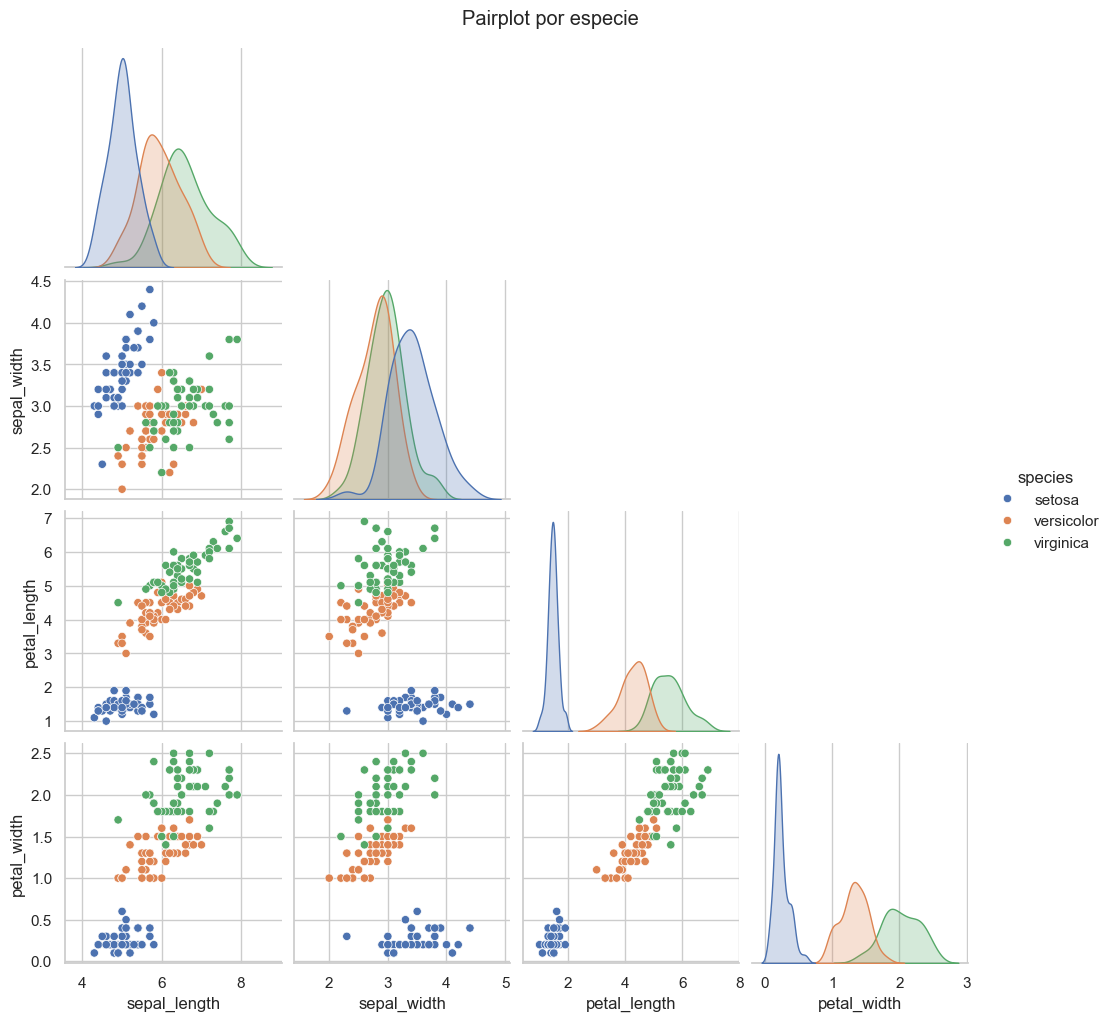

In [5]:
feats = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
sns.pairplot(df, hue="species", corner=True, diag_kind="kde")
plt.suptitle("Pairplot por especie", y=1.02)
plt.show()

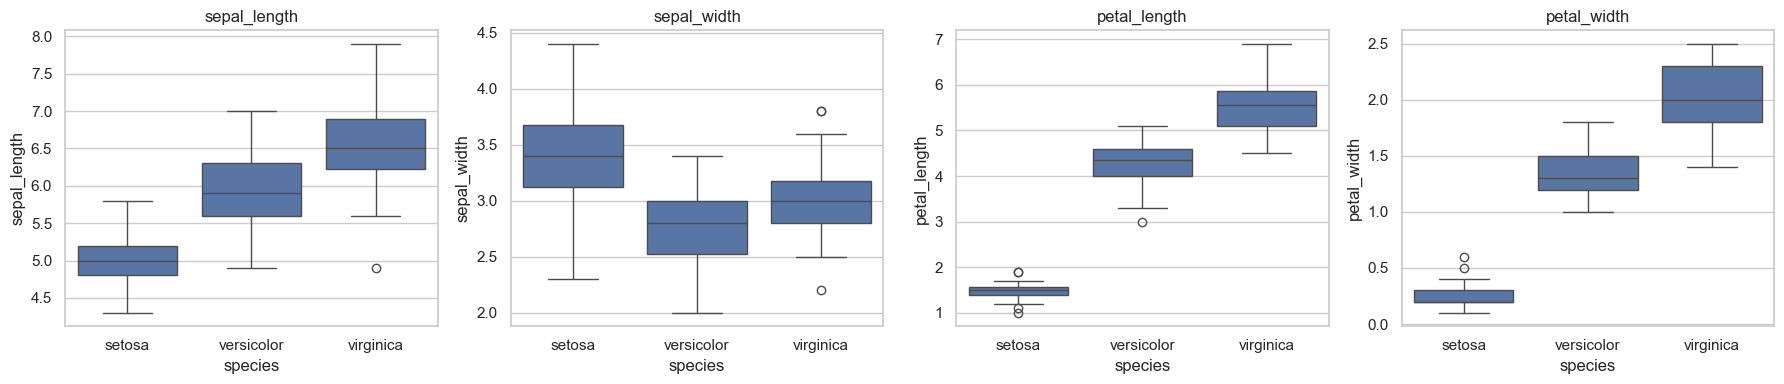

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, feats):
    sns.boxplot(data=df, x="species", y=c, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

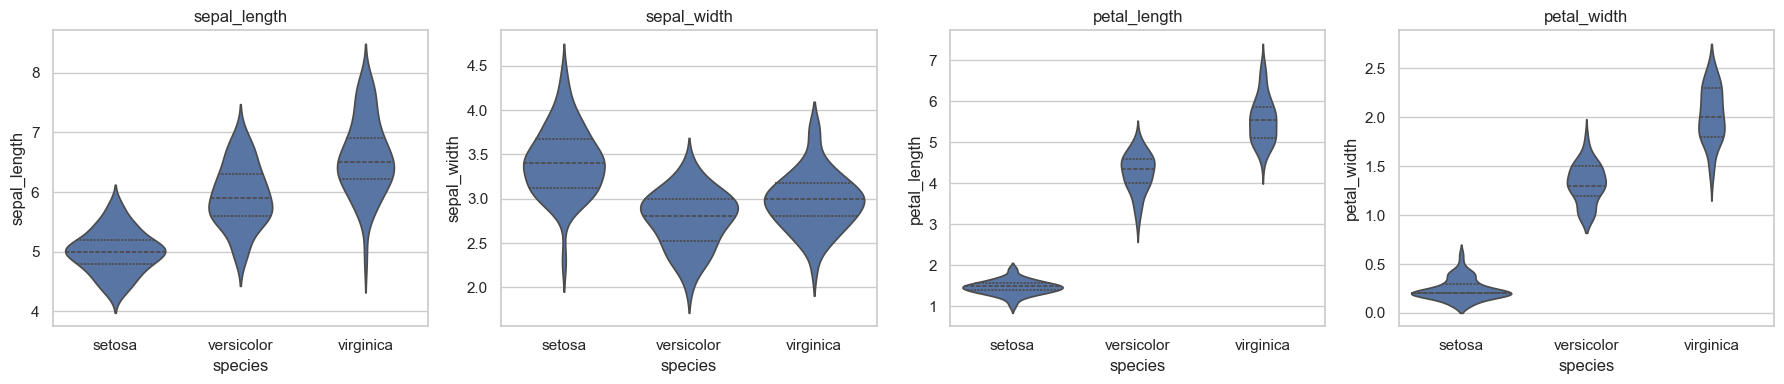

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, feats):
    sns.violinplot(data=df, x="species", y=c, ax=ax, inner="quartile")
    ax.set_title(c)
plt.tight_layout()
plt.show()

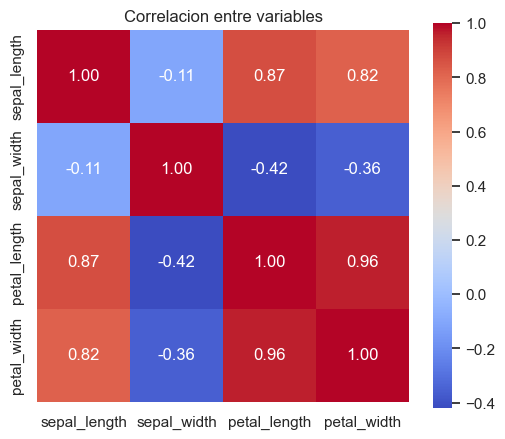

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[feats].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlacion entre variables")
plt.show()

In [9]:
fig = px.scatter_3d(df, x="petal_length", y="petal_width", z="sepal_length",
                    color="species", symbol="species", opacity=0.8,
                    title="Iris en 3D")
fig.update_traces(marker_size=5)
fig

In [10]:
dfp = df.copy()
dfp["species_code"] = LabelEncoder().fit_transform(dfp["species"])
fig = px.parallel_coordinates(dfp, dimensions=feats, color="species_code",
                              color_continuous_scale=px.colors.sequential.Viridis,
                              title="Coordenadas paralelas por especie")
fig

Setosa se separa sola; versicolor y virginica se solapan. El pétalo separa más que el sepal.

### 2.1 Selección de características

Lo confirmo con un ANOVA F (`f_classif`): a mayor F-score, mejor separa la variable.

In [11]:
F_scores, p_values = f_classif(df[feats], dfp["species_code"])
anova = pd.DataFrame({"feature": feats, "F_score": F_scores, "p_value": p_values}) \
    .sort_values("F_score", ascending=False).reset_index(drop=True)
anova

,feature,F_score,p_value
0,petal_length,1179.034328,3.051976e-91
1,petal_width,959.324406,4.376957e-85
2,sepal_length,119.264502,1.669669e-31
3,sepal_width,47.364461,1.327917e-16


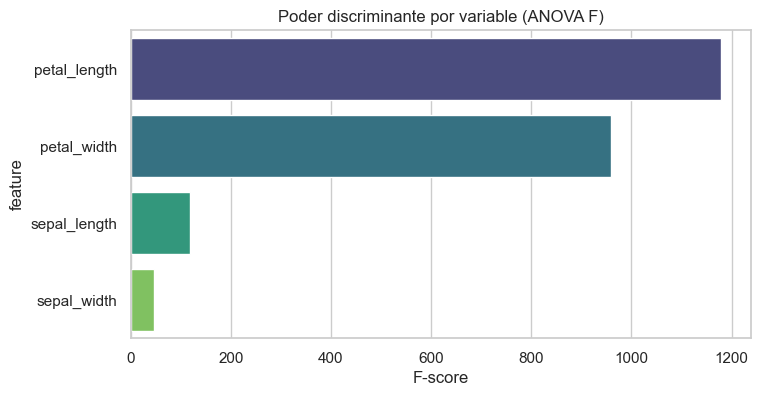

In [12]:
plt.figure(figsize=(8, 4))
sns.barplot(data=anova, x="F_score", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Poder discriminante por variable (ANOVA F)")
plt.xlabel("F-score")
plt.show()

El pétalo gana por mucho. El modelo reducido usa solo `petal_length` y `petal_width`; el completo, las cuatro.

## 3. Preparación de los datos

One-hot a la etiqueta, split estratificado 80/20 y estandarización ajustando el scaler solo en train (sin leakage).

In [13]:
le = LabelEncoder()
y = le.fit_transform(df["species"])
y_cat = keras.utils.to_categorical(y, num_classes=3)
class_names = list(le.classes_)

feat_full = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
feat_petalo = ["petal_length", "petal_width"]
X_full = df[feat_full].values
X_pet = df[feat_petalo].values

class_names, y_cat.shape

(['setosa', 'versicolor', 'virginica'], (150, 3))

In [14]:
idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test, y_train_cat, y_test_cat = train_test_split(
    idx, y, y_cat, test_size=0.2, stratify=y, random_state=42)

scaler_full = StandardScaler().fit(X_full[idx_train])
Xf_train = scaler_full.transform(X_full[idx_train])
Xf_test = scaler_full.transform(X_full[idx_test])

scaler_pet = StandardScaler().fit(X_pet[idx_train])
Xp_train = scaler_pet.transform(X_pet[idx_train])
Xp_test = scaler_pet.transform(X_pet[idx_test])

print("train:", Xf_train.shape, "| test:", Xf_test.shape)
print("balance train:", np.bincount(y_train), "| balance test:", np.bincount(y_test))

train: (120, 4) | test: (30, 4)
balance train: [40 40 40] | balance test: [10 10 10]


## 4. Modelado

Pruebo tres arquitecturas con las cuatro features. Salida `softmax` de 3 con `categorical_crossentropy` (multiclase), `ReLU` en las ocultas, `Adam` y `EarlyStopping` para no sobreajustar.

In [15]:
def build_model(n_features, hidden, name):
    keras.utils.set_random_seed(42)
    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=(n_features,)))
    for h in hidden:
        model.add(layers.Dense(h, activation="relu"))
    model.add(layers.Dense(3, activation="softmax"))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

EPOCHS = 200

def make_early():
    return keras.callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                         restore_best_weights=True)

archs = {
    "NN1_simple": [8],
    "NN2_media": [16, 8],
    "NN3_profunda": [32, 16, 8],
}
build_model(4, archs["NN2_media"], "demo").summary()

Model: "demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
histories = {}
fitted = {}
for name, hidden in archs.items():
    m = build_model(4, hidden, name)
    h = m.fit(Xf_train, y_train_cat, validation_split=0.2, epochs=EPOCHS,
              batch_size=16, callbacks=[make_early()], verbose=0)
    histories[name] = h
    fitted[name] = m
    loss, acc = m.evaluate(Xf_test, y_test_cat, verbose=0)
    print(f"{name:14s} | epochs={len(h.history['loss']):3d} | test_acc={acc:.4f}")

NN1_simple     | epochs=100 | test_acc=0.9667


NN2_media      | epochs= 65 | test_acc=0.9667


NN3_profunda   | epochs= 45 | test_acc=0.9667


In [17]:
rows = []
for name, m in fitted.items():
    pred = m.predict(Xf_test, verbose=0).argmax(axis=1)
    rows.append({
        "modelo": name,
        "n_features": 4,
        "params": m.count_params(),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred, average="macro"), 4),
        "recall": round(recall_score(y_test, pred, average="macro"), 4),
        "f1_macro": round(f1_score(y_test, pred, average="macro"), 4),
        "epochs": len(histories[name].history["loss"]),
    })
tabla_full = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
tabla_full

,modelo,n_features,params,accuracy,precision,recall,f1_macro,epochs
0,NN1_simple,4,67,0.9667,0.9697,0.9667,0.9666,100
1,NN2_media,4,243,0.9667,0.9697,0.9667,0.9666,65
2,NN3_profunda,4,851,0.9667,0.9697,0.9667,0.9666,45


### 4.1 Curvas de entrenamiento

Pérdida y accuracy de train y validación vs. epochs.

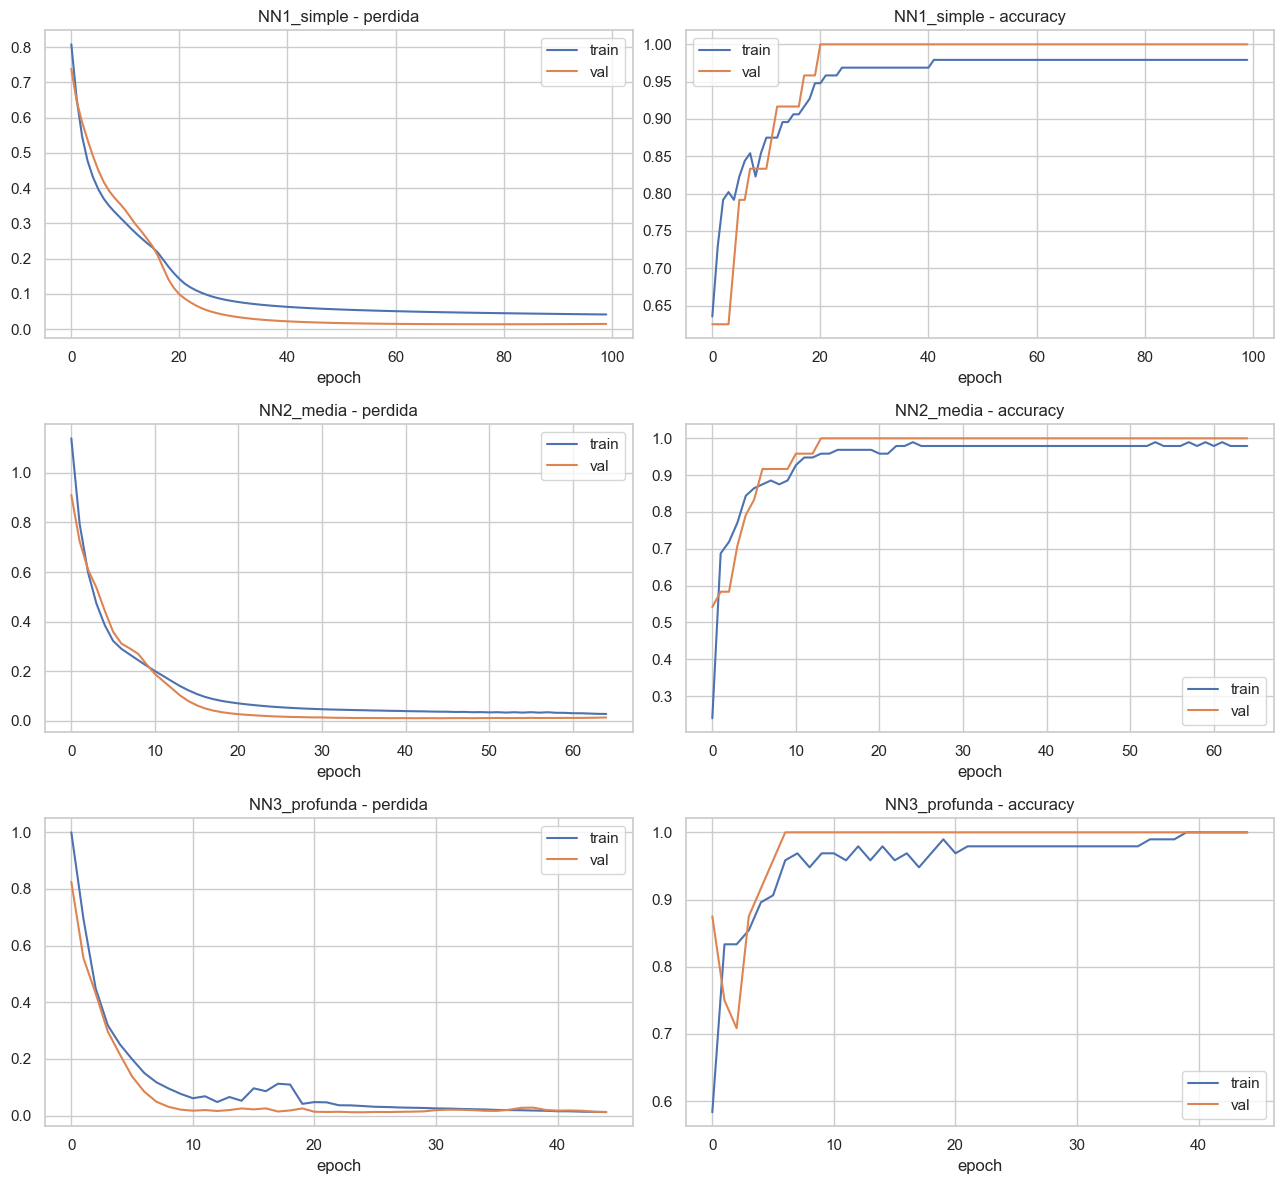

In [18]:
fig, axes = plt.subplots(len(archs), 2, figsize=(13, 4 * len(archs)))
for i, name in enumerate(archs):
    h = histories[name].history
    axes[i, 0].plot(h["loss"], label="train")
    axes[i, 0].plot(h["val_loss"], label="val")
    axes[i, 0].set_title(f"{name} - perdida"); axes[i, 0].set_xlabel("epoch"); axes[i, 0].legend()
    axes[i, 1].plot(h["accuracy"], label="train")
    axes[i, 1].plot(h["val_accuracy"], label="val")
    axes[i, 1].set_title(f"{name} - accuracy"); axes[i, 1].set_xlabel("epoch"); axes[i, 1].legend()
plt.tight_layout()
plt.show()

### 4.2 Misma arquitectura, solo pétalo

Re-entreno la mejor arquitectura con las dos variables de pétalo, dejando todo lo demás igual.

In [19]:
best_arch = tabla_full.iloc[0]["modelo"]
best_hidden = archs[best_arch]
print("Mejor arquitectura (4 features):", best_arch, "| capas ocultas:", best_hidden)

m_pet = build_model(2, best_hidden, f"{best_arch}_petalo")
h_pet = m_pet.fit(Xp_train, y_train_cat, validation_split=0.2, epochs=EPOCHS,
                  batch_size=16, callbacks=[make_early()], verbose=0)
histories[f"{best_arch}_petalo"] = h_pet

pred_pet = m_pet.predict(Xp_test, verbose=0).argmax(axis=1)
print("epochs:", len(h_pet.history["loss"]))

Mejor arquitectura (4 features): NN1_simple | capas ocultas: [8]


epochs: 133


In [20]:
best_row = tabla_full.iloc[0]
comp = pd.DataFrame([
    {"modelo": f"{best_arch} (4 features)", "n_features": 4,
     "accuracy": best_row["accuracy"], "precision": best_row["precision"],
     "recall": best_row["recall"], "f1_macro": best_row["f1_macro"],
     "epochs": int(best_row["epochs"])},
    {"modelo": f"{best_arch} (2 features petalo)", "n_features": 2,
     "accuracy": round(accuracy_score(y_test, pred_pet), 4),
     "precision": round(precision_score(y_test, pred_pet, average="macro"), 4),
     "recall": round(recall_score(y_test, pred_pet, average="macro"), 4),
     "f1_macro": round(f1_score(y_test, pred_pet, average="macro"), 4),
     "epochs": len(h_pet.history["loss"])},
])
comp

,modelo,n_features,accuracy,precision,recall,f1_macro,epochs
0,NN1_simple (4 features),4,0.9667,0.9697,0.9667,0.9666,100
1,NN1_simple (2 features petalo),2,0.9667,0.9697,0.9667,0.9666,133


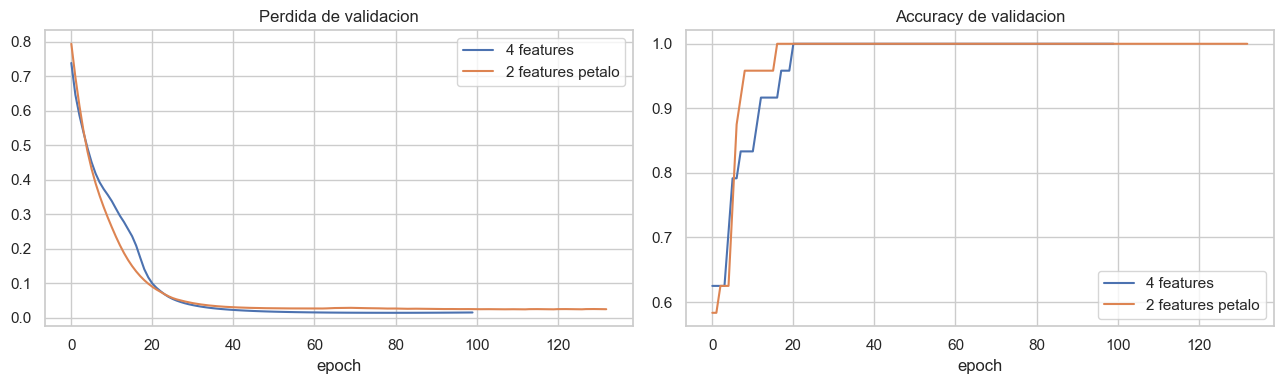

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hf = histories[best_arch].history
hp = h_pet.history
axes[0].plot(hf["val_loss"], label="4 features")
axes[0].plot(hp["val_loss"], label="2 features petalo")
axes[0].set_title("Perdida de validacion"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(hf["val_accuracy"], label="4 features")
axes[1].plot(hp["val_accuracy"], label="2 features petalo")
axes[1].set_title("Accuracy de validacion"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Evaluación

Reporte por clase, matriz de confusión y frontera de decisión, para el modelo completo y el reducido.

In [22]:
pred_full = fitted[best_arch].predict(Xf_test, verbose=0).argmax(axis=1)
print("=== Modelo completo (4 features):", best_arch, "===")
print(classification_report(y_test, pred_full, target_names=class_names))

=== Modelo completo (4 features): NN1_simple ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [23]:
print("=== Modelo reducido (2 features petalo) ===")
print(classification_report(y_test, pred_pet, target_names=class_names))

=== Modelo reducido (2 features petalo) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



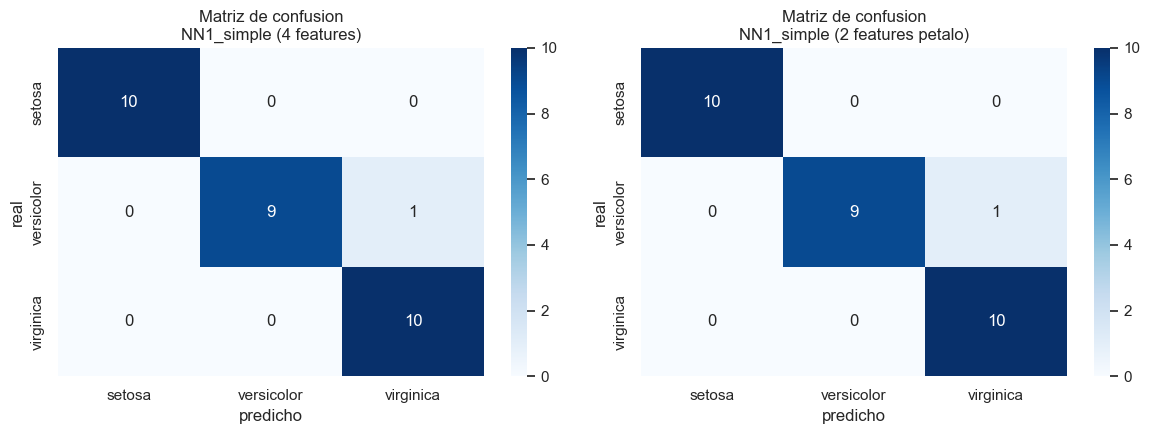

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, pred, titulo in [(axes[0], pred_full, f"{best_arch} (4 features)"),
                         (axes[1], pred_pet, f"{best_arch} (2 features petalo)")]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Matriz de confusion\n{titulo}")
    ax.set_ylabel("real"); ax.set_xlabel("predicho")
plt.tight_layout()
plt.show()

### 5.1 Frontera de decisión con PCA

Proyecto a 2D con PCA (ajustado en train), entreno una red gemela en ese espacio y dibujo la superficie con `contourf` y los puntos de test encima. Lo repito para cada arquitectura entrenada: las tres con las cuatro features y la reducida de pétalo.

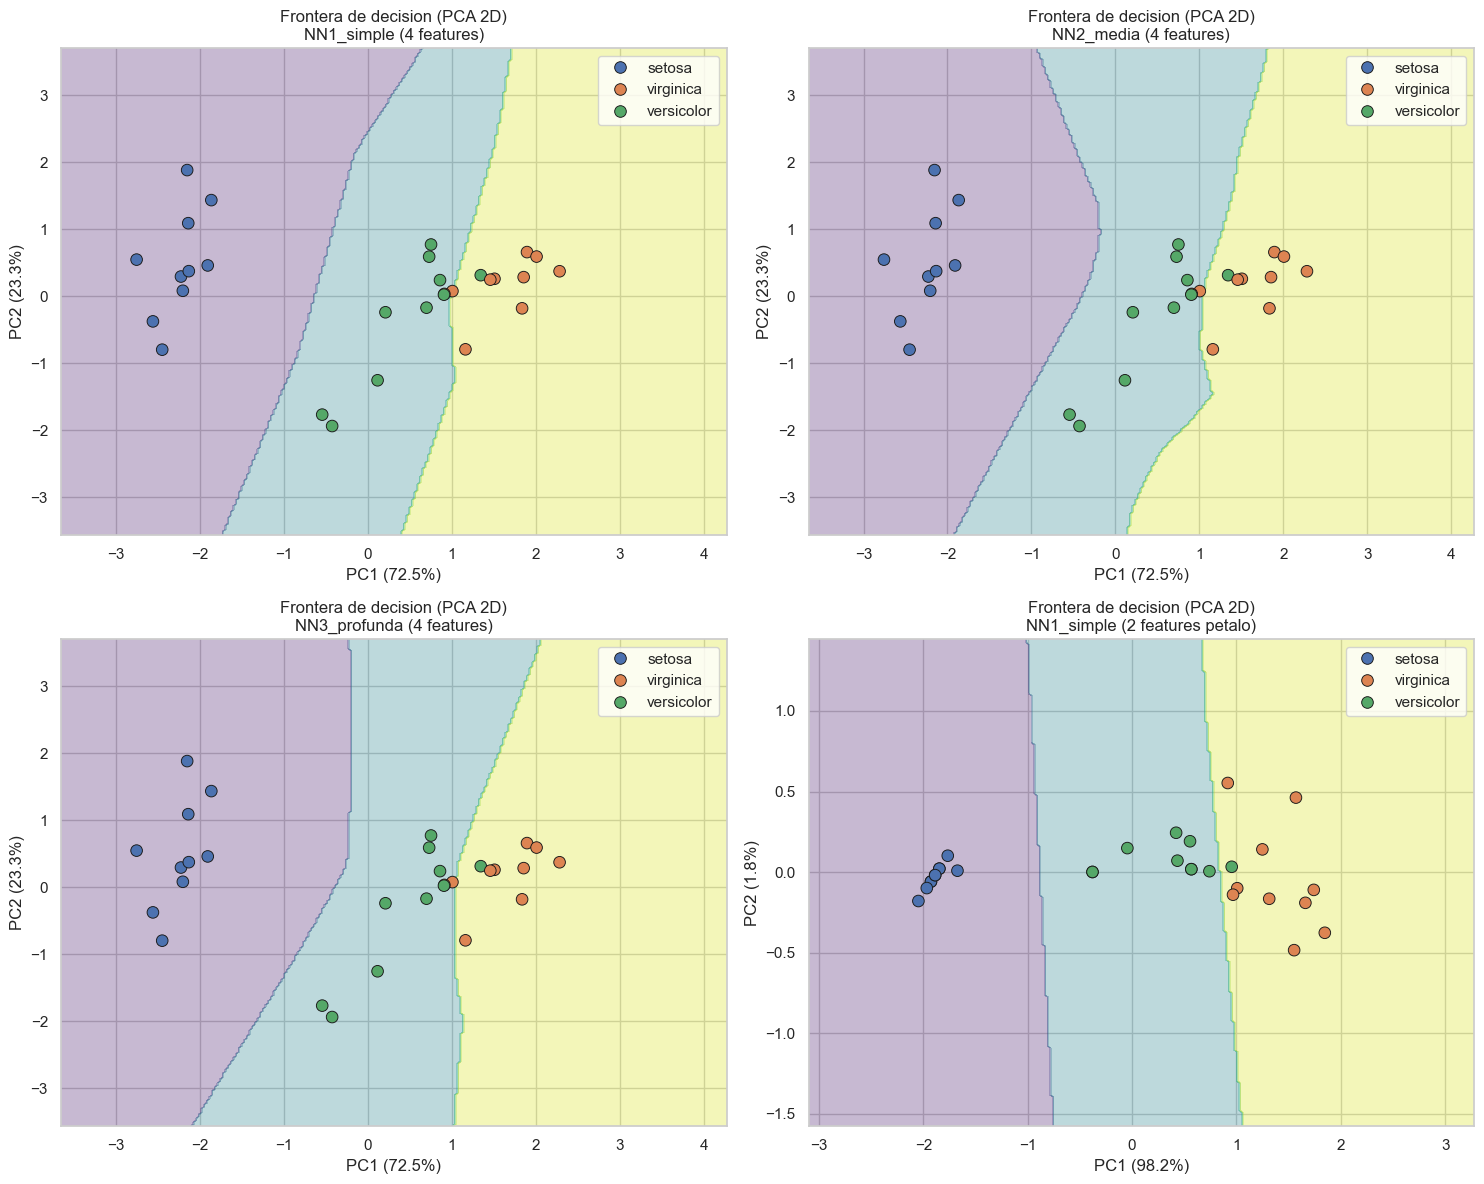

In [25]:
def frontera_pca(X_tr, X_te, hidden, titulo, ax):
    pca = PCA(n_components=2, random_state=42).fit(X_tr)
    Z_tr, Z_te = pca.transform(X_tr), pca.transform(X_te)
    clf = build_model(2, hidden, "pca")
    clf.fit(Z_tr, y_train_cat, epochs=EPOCHS, batch_size=16,
            callbacks=[make_early()], validation_split=0.2, verbose=0)
    xx, yy = np.meshgrid(
        np.linspace(Z_tr[:, 0].min() - 1, Z_tr[:, 0].max() + 1, 250),
        np.linspace(Z_tr[:, 1].min() - 1, Z_tr[:, 1].max() + 1, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    ZZ = clf.predict(grid, verbose=0).argmax(axis=1).reshape(xx.shape)
    ax.contourf(xx, yy, ZZ, alpha=0.3, cmap="viridis")
    sns.scatterplot(x=Z_te[:, 0], y=Z_te[:, 1], hue=le.inverse_transform(y_test),
                    palette="deep", edgecolor="k", s=70, ax=ax)
    var = pca.explained_variance_ratio_
    ax.set_title(f"Frontera de decision (PCA 2D)\n{titulo}")
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")

paneles = [(name, Xf_train, Xf_test, archs[name], f"{name} (4 features)") for name in archs]
paneles.append((f"{best_arch}_petalo", Xp_train, Xp_test, best_hidden,
                f"{best_arch} (2 features petalo)"))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, (_, X_tr, X_te, hidden, titulo) in zip(axes.ravel(), paneles):
    frontera_pca(X_tr, X_te, hidden, titulo, ax)
plt.tight_layout()
plt.show()

### 5.2 Comparativa con y sin selección de features

Todas las redes en una tabla.

In [26]:
fila_pet = {
    "modelo": f"{best_arch}_petalo", "n_features": 2, "params": m_pet.count_params(),
    "accuracy": round(accuracy_score(y_test, pred_pet), 4),
    "precision": round(precision_score(y_test, pred_pet, average="macro"), 4),
    "recall": round(recall_score(y_test, pred_pet, average="macro"), 4),
    "f1_macro": round(f1_score(y_test, pred_pet, average="macro"), 4),
    "epochs": len(h_pet.history["loss"]),
}
tabla_final = pd.concat([tabla_full, pd.DataFrame([fila_pet])], ignore_index=True) \
    .sort_values("f1_macro", ascending=False).reset_index(drop=True)
tabla_final

,modelo,n_features,params,accuracy,precision,recall,f1_macro,epochs
0,NN1_simple,4,67,0.9667,0.9697,0.9667,0.9666,100
1,NN2_media,4,243,0.9667,0.9697,0.9667,0.9666,65
2,NN3_profunda,4,851,0.9667,0.9697,0.9667,0.9666,45
3,NN1_simple_petalo,2,51,0.9667,0.9697,0.9667,0.9666,133


In [27]:
fig = go.Figure()
fig.add_trace(go.Bar(x=tabla_final["modelo"], y=tabla_final["accuracy"], name="accuracy"))
fig.add_trace(go.Bar(x=tabla_final["modelo"], y=tabla_final["f1_macro"], name="f1_macro"))
fig.update_layout(barmode="group", title="Comparativa de modelos (accuracy y F1-macro en test)",
                  yaxis_range=[0.8, 1.0], xaxis_title="modelo", yaxis_title="metrica")
fig

## 6. Conclusiones

La red con solo el pétalo iguala en test a la de cuatro features (mismo accuracy y F1), así que reducir no degradó la performance y dejó una frontera más limpia. Los pocos errores caen siempre entre versicolor y virginica.

Una salvedad para ser honesto: el modelo de dos features no entrenó más fácil en sentido estricto. Con cuatro variables el EarlyStopping cortó a las 100 epochs, mientras que con dos la validación siguió mejorando de a poco y recién frenó a las 133. Tiene sentido: al sacar el sepal hay menos señal por paso, así que la red necesita más pasadas para llegar al mismo punto. No es que la optimización sea más dura (llega igual de bien), sino que tarda algunas epochs más en estabilizarse; y como cada epoch es más barata con la mitad de entradas, el costo total termina parejo. El entrenamiento no se complicó, pero sí pidió más epochs, y vale dejarlo dicho en vez de barrerlo.

Para identificar una flor nueva alcanza con el pétalo.

Bonus: exporto a Excel la arquitectura de dos modelos, el de cuatro features y el reducido de pétalo.

In [28]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

xlsx_path = "arquitectura_redes-secuenciales-iris.xlsx"

wb = openpyxl.Workbook()
wb.remove(wb.active)

thin = Side(style="thin", color="999999")
border = Border(left=thin, right=thin, top=thin, bottom=thin)
hdr_fill = PatternFill("solid", fgColor="1F4E78")
hdr_font = Font(bold=True, color="FFFFFF")
sub_fill = PatternFill("solid", fgColor="D9E1F2")
bias_fill = PatternFill("solid", fgColor="FCE4D6")


def style_header(ws, row, c0, c1):
    for c in range(c0, c1 + 1):
        cell = ws.cell(row=row, column=c)
        cell.fill = hdr_fill
        cell.font = hdr_font
        cell.alignment = Alignment(horizontal="center", vertical="center")
        cell.border = border


def exportar_modelo(model, hidden, input_names, etiqueta):
    weights = model.get_weights()
    capas = [("oculta", d, "ReLU") for d in hidden] + [("salida", 3, "softmax")]

    ws = wb.create_sheet(f"Forward {etiqueta}")
    in_names = list(input_names)
    in_count = len(input_names)
    row = 1
    for li, (tipo, n_neur, act) in enumerate(capas):
        ws.cell(row=row, column=1, value=f"Capa {li+1} ({tipo}) - {n_neur} neuronas - {act}")
        ws.cell(row=row, column=1).font = Font(bold=True, size=11, color="1F4E78")
        row += 1
        headers = ["neurona", "BIAS"] + [f"w_{nm}" for nm in in_names] + \
                  ["z = BIAS + sum(w*x)", f"activacion = {act}(z)"]
        for j, htext in enumerate(headers, start=1):
            ws.cell(row=row, column=j, value=htext)
        style_header(ws, row, 1, len(headers))
        row += 1
        W = weights[2 * li]
        b = weights[2 * li + 1]
        for nrn in range(n_neur):
            ws.cell(row=row, column=1, value=f"n{nrn+1}")
            bcell = ws.cell(row=row, column=2, value=round(float(b[nrn]), 5))
            bcell.fill = bias_fill
            for k in range(in_count):
                ws.cell(row=row, column=3 + k, value=round(float(W[k, nrn]), 5))
            col_z = 3 + in_count
            ws.cell(row=row, column=col_z, value="z = BIAS + sum(w_i * input_i)")
            ws.cell(row=row, column=col_z + 1,
                    value=("max(0, z)" if act == "ReLU" else "exp(z)/sum(exp(z))"))
            for c in range(1, col_z + 2):
                ws.cell(row=row, column=c).border = border
            row += 1
        in_names = [f"a_{li+1}_n{i+1}" for i in range(n_neur)]
        in_count = n_neur
        row += 1
    for col, w in zip("ABCDEFGH", [12, 12, 16, 16, 16, 16, 26, 26]):
        ws.column_dimensions[col].width = w

    ws2 = wb.create_sheet(f"Pesos {etiqueta}")
    r = 1
    in_names = list(input_names)
    for li, (tipo, n_neur, act) in enumerate(capas):
        W = weights[2 * li]
        b = weights[2 * li + 1]
        ws2.cell(row=r, column=1,
                 value=f"Capa {li+1} ({tipo}) - W {W.shape} - b {b.shape} - {act}")
        ws2.cell(row=r, column=1).font = Font(bold=True, size=11, color="1F4E78")
        r += 1
        ws2.cell(row=r, column=1, value="peso \\ neurona")
        for nrn in range(n_neur):
            ws2.cell(row=r, column=2 + nrn, value=f"n{nrn+1}")
        style_header(ws2, r, 1, 1 + n_neur)
        r += 1
        for k, nm in enumerate(in_names):
            ws2.cell(row=r, column=1, value=nm).fill = sub_fill
            for nrn in range(n_neur):
                ws2.cell(row=r, column=2 + nrn, value=round(float(W[k, nrn]), 6))
            r += 1
        ws2.cell(row=r, column=1, value="BIAS").fill = bias_fill
        for nrn in range(n_neur):
            c = ws2.cell(row=r, column=2 + nrn, value=round(float(b[nrn]), 6))
            c.fill = bias_fill
        r += 2
        in_names = [f"a_{li+1}_n{i+1}" for i in range(n_neur)]
    ws2.column_dimensions["A"].width = 18
    max_neur = max(c[1] for c in capas)
    for j in range(2, 2 + max_neur):
        ws2.column_dimensions[openpyxl.utils.get_column_letter(j)].width = 12


exportar_modelo(fitted[best_arch], best_hidden, feat_full, "4feat")
exportar_modelo(m_pet, best_hidden, feat_petalo, "petalo")

wb.save(xlsx_path)
print("Excel generado:", xlsx_path, "| hojas:", wb.sheetnames)

Excel generado: arquitectura_redes-secuenciales-iris.xlsx | hojas: ['Forward 4feat', 'Pesos 4feat', 'Forward petalo', 'Pesos petalo']
